In [1]:
%run functions.ipynb

import os

os.makedirs("../submission", exist_ok=True)

# Start from a clean submission so the notebooks can be re-run in order
for file in ["../submission/forecasts.csv", "../submission/metrics.csv"]:
    if os.path.exists(file):
        os.remove(file)

df = load_data()
df.head()

,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [2]:
plot_time_series(df)

<Figure size 1200x400 with 1 Axes>

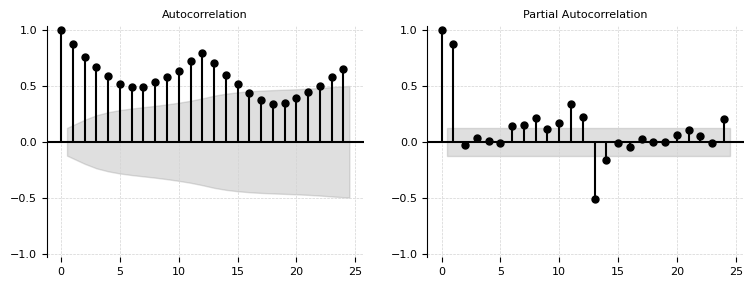

In [3]:
acf_pacf_plots(df.yt_true)

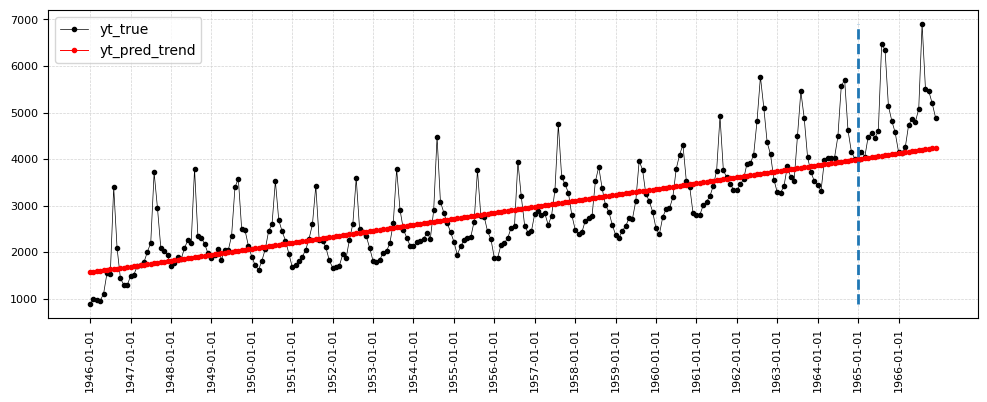

In [4]:
# Model 1: linear trend
from sklearn.linear_model import LinearRegression

df = add_linear_trend_component(df)
X_complete, y_complete, X_train, y_train, X_test, y_test = train_test_split(
    df, ["trend"], "yt_true"
)

model = LinearRegression().fit(X_train, y_train)
df["yt_pred_trend"] = model.predict(X_complete)
plot_time_series(df)

In [5]:
metrics = compute_evaluation_metrics(df)
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_trend
0,MSE Train,376582.81
1,MSE Test,1146851.21
2,MAE Train,459.62
3,MAE Test,781.18
